<a href="https://colab.research.google.com/github/janani-tamilarasan/AI-Resource/blob/main/linear_regression/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression

### 1. Business Understanding
  Predict MPG (Miles Per Gallon) of a car.

  **Target Variable**: MPG

 **Input Variables:** HP VOL SP	WT

### 1.1 Import libraries

In [164]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_squared_error
import numpy as np
from pickle import dump, load




### 2. Data Collection/Load Dataset

In [165]:
cars_data = pd.read_csv(
    "https://raw.githubusercontent.com/janani-tamilarasan/AI-Resource/main/Machine%20Learning/linear_regression/Cars.csv"
)
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


### 3. Data Understanding


In [166]:
print(cars_data.shape,)
print("------------","\n")
print(cars_data.info)
print("------------","\n")
print(cars_data.isna().sum())
print("------------","\n")
print(cars_data.dtypes)
print("------------","\n")
print(cars_data.describe())

(81, 5)
------------ 

<bound method DataFrame.info of      HP        MPG  VOL          SP         WT
0    49  53.700681   89  104.185353  28.762059
1    55  50.013401   92  105.461264  30.466833
2    55  50.013401   92  105.461264  30.193597
3    70  45.696322   92  113.461264  30.632114
4    53  50.504232   92  104.461264  29.889149
..  ...        ...  ...         ...        ...
76  322  36.900000   50  169.598513  16.132947
77  238  19.197888  115  150.576579  37.923113
78  263  34.000000   50  151.598513  15.769625
79  295  19.833733  119  167.944460  39.423099
80  236  12.101263  107  139.840817  34.948615

[81 rows x 5 columns]>
------------ 

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64
------------ 

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object
------------ 

               HP        MPG         VOL          SP         WT
count   81.000000  81.000000   81.000000   81.000000  81.000000
mean   117.469136  34.422076   98.765

#### 3.1  Exploratory Data Analysis (EDA)

#### 3.1.a Linearity Test - **FAILED**

Downward slope → negative relationship.

Upward slope → positive relationship.

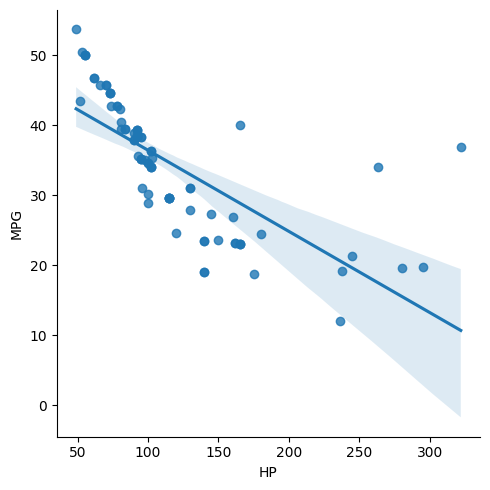

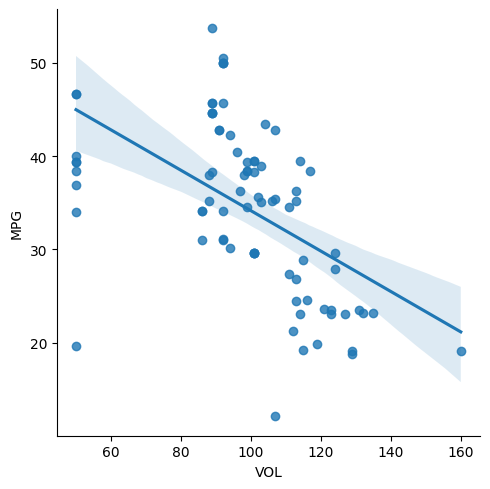

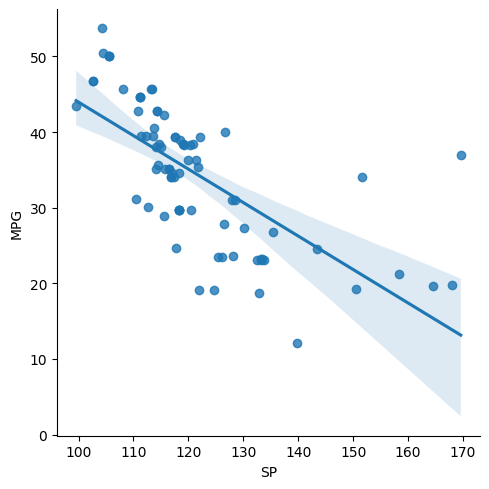

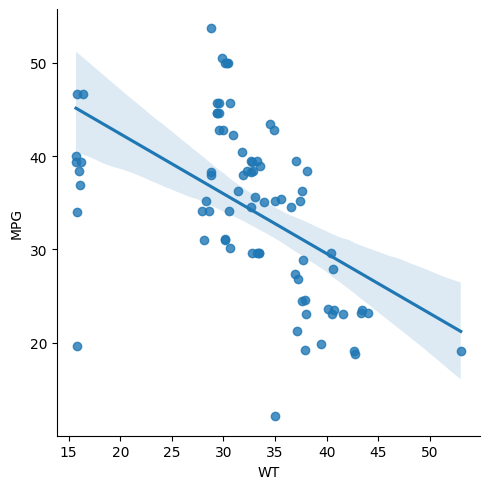

In [167]:
### lmplot() is a Seaborn function used to visualize the linear relationship between two variables
x = ["HP","VOL","SP","WT"]
y = "MPG"
sns.lmplot(data = cars_data,x= "HP",y = "MPG")
sns.lmplot(data = cars_data,x= "VOL",y = "MPG")
sns.lmplot(data = cars_data,x= "SP",y = "MPG")
sns.lmplot(data = cars_data,x= "WT",y = "MPG")
plt.show()

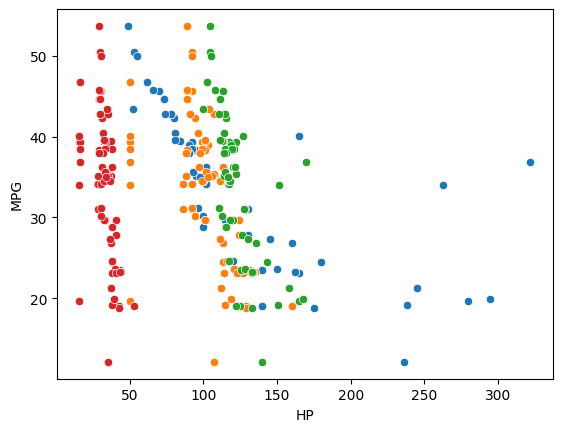

In [168]:
### A scatter plot is used to show the relationship between two numerical variables. In Linear Regression, it helps us check the linearity assumption.

sns.scatterplot(data = cars_data,x= "HP",y = "MPG")
sns.scatterplot(data = cars_data,x= "VOL",y = "MPG")
sns.scatterplot(data = cars_data,x= "SP",y = "MPG")
sns.scatterplot(data = cars_data,x= "WT",y = "MPG")
plt.show()


#### 3.1.b Normatlity Test - **FAILED**

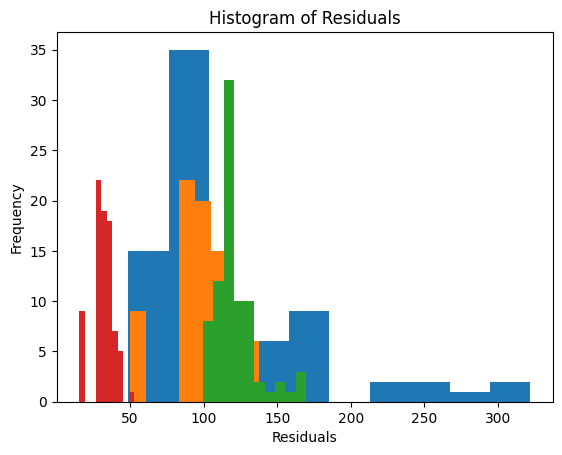

In [169]:
# Histogram -> Bell-shaped histogram → Normal distribution.Skewed histogram → Not normal.

plt.hist(cars_data["HP"])
plt.hist(cars_data["VOL"])
plt.hist(cars_data["SP"])
plt.hist(cars_data["WT"])
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

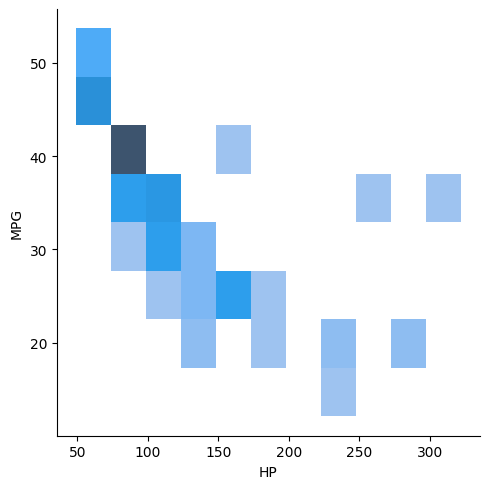

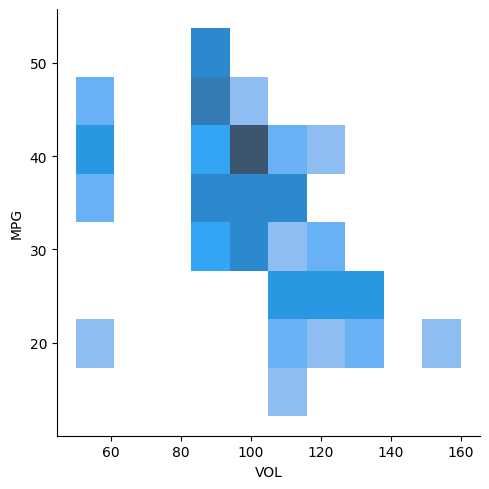

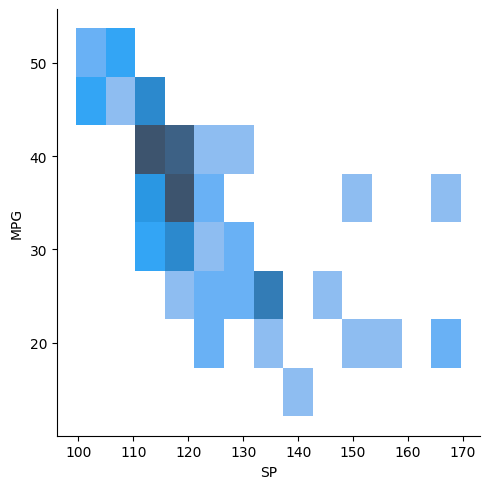

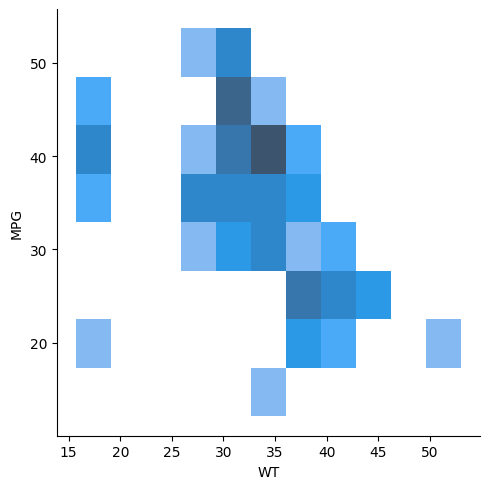

In [170]:
### Displot

sns.displot(data = cars_data, x = "HP" , y = "MPG")
sns.displot(data = cars_data, x = "VOL" , y = "MPG")
sns.displot(data = cars_data, x = "SP" , y = "MPG")
sns.displot(data = cars_data, x = "WT" , y = "MPG")
plt.show()

#### 3.1.c Correlation Matrix
A correlation matrix shows the relationship between all numerical variables. The correlation values range from -1 to +1.

+1 → Perfect positive correlation
-1 → Perfect negative correlation
0 → No relationship

NOTE:

Multicollinearity means:

Two or more independent variables are highly correlated with each other.

For example:

HP and SP are highly related.
WT and VOL may be related.

This causes problems because the model cannot determine which variable is actually influencing MPG.

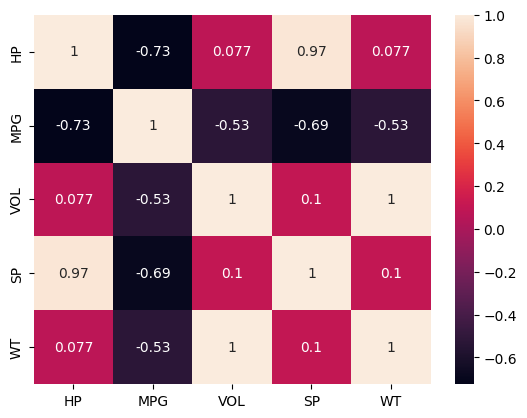

In [171]:
### HEatMAp -> A heatmap is a graphical representation of data where colors represent values.

# In Machine Learning, we use a correlation heatmap to visualize the correlation matrix.

# Dark/Hot colors → Strong correlation.
# Light colors → Weak correlation.
# Positive values (+) → Variables move together.
# Negative values (-) → Variables move in opposite directions.
corr_cars = cars_data.corr()

sns.heatmap(corr_cars,annot=True)
plt.show()

### 4. Data Preparation -

In [172]:
#There is nothing to prepare because all features are numeric.
cars_data.dtypes

,0
HP,int64
MPG,float64
VOL,int64
SP,float64
WT,float64


In [173]:
#### 4.1  Train-Test Split
X = cars_data[["HP","VOL","SP","WT"]]
Y = cars_data['MPG']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.02, random_state= 42, shuffle= True)


### 5. Model Building



In [174]:
linear_model = LinearRegression()


### 6. Model Training


In [175]:
### 6. Model Training / Predict
linear_model.fit(X_train, Y_train)
linear_model.intercept_
linear_model.coef_

array([-0.20138879, -0.6576168 ,  0.39418825,  1.35828434])

### 7. Model Testing

In [176]:
y_pred = linear_model.predict(X_test)
y_pred

array([34.05391914, 42.63029921])

### 8. Model Evaluation

#### 8.1.a Homoscedasticity Test FAILED


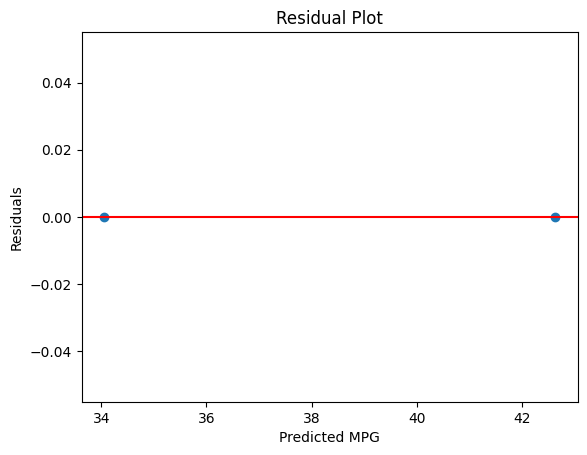

In [177]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

#### 8.1.b Zero Residual Mean Test
residuals = y_test - y_pred

print(residuals.mean())

#### 8.1  MAE (Mean Absolute Error) - Measures the average absolute error.

In [178]:
#### 8.1  MAE (Mean Absolute Error)
mae = mean_absolute_error(Y_test, y_pred)
print(mae)

8.223849115020375


#### 8.2  MSE (Mean Squared Error) - Squares the errors before averaging.


In [179]:
#### 8.2  MSE (Mean Squared Error)
mse = mean_squared_error(Y_test, y_pred)
print(mse)

75.73444470107563


#### 8.3 RMSE (Root Mean Squared Error)

In [180]:
rmse = np.sqrt(mse)
print(rmse)

8.702553918309018


#### 8.4 R² Score (Coefficient of Determination)

In [181]:
r2 = r2_score(y_test, y_pred)
print(r2)

1.0


#### 8.5  MAPE (Mean Absolute Percentage Error)

In [182]:
### MAPE (Mean Absolute Percentage Error)

mse = mean_squared_error(Y_test, y_pred)
print(mse)

75.73444470107563


### 9. Model Deployment

In [183]:
dump(obj = linear_model,file = open(file = "linear_intelligence_file.pkl", mode='wb'))
linear_intel_pkl = load(file = open(file = "linear_intelligence_file.pkl", mode='rb'))
linear_intel_pkl.predict(X_test)

array([34.05391914, 42.63029921])